# Model 05 — NLP-Enhanced 3-Layer XGBoost
**Baseline (NB03) + News Sentiment Layer**

---

| | Notebook 03 (Baseline) | **Notebook 05 (This)** |
|---|---|---|
| Layer 1 | Macro fundamentals | Macro fundamentals |
| Layer 2 | Market + VIX regime | Market + VIX regime |
| Layer 3 | — | **NLP Sentiment (NEW)** |
| Targets | SET / Gold / USD-THB | SET / Gold / USD-THB |

### Structure
- **Part 1** — Full History (2000–2025): Does NLP hurt or help when data is sparse?
- **Part 2** — NLP Era (2023–2025): Real performance when news data is available
- **Part 3** — Feature Importance: Which NLP signals actually matter?
- **Part 4** — This Week's Prediction: What does the model say right now?

In [1]:
import warnings; warnings.filterwarnings('ignore')
import optuna; optuna.logging.set_verbosity(optuna.logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score
from pathlib import Path

try:
    import shap; SHAP_OK = True
except ImportError:
    SHAP_OK = False

ROOT = Path('../../')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Setup OK')

Setup OK


In [2]:
# ── Feature Groups ─────────────────────────────────────────────────────────
TARGETS = ['SET_index_ret_w', 'gold_ret_w', 'USD_THB_ret_w']
TARGET_LABELS = {'SET_index_ret_w': 'SET Index', 'gold_ret_w': 'Gold', 'USD_THB_ret_w': 'USD/THB'}

MACRO = [
    'us_industrial_prod', 'us_cpi_monthly', 'us_fed_funds_rate',
    'us_unemployment', 'gdp_growth_annual', 'inflation_annual',
    'us_govt_spending', 'th_exchange_rate_real',
]
MARKET = [
    'sp500_ret_w', 'nasdaq_ret_w', 'vix_price', 'dxy_ret_w',
    'oil_ret_w', 'us_10yr_treasury_ret_w',
    'sp500_ret_d_lag1', 'nasdaq_ret_d_lag1', 'eem_ret_d_lag1',
]
NLP = [
    'sent_mean_1w', 'sent_vol_4w', 'sent_mom4w', 'sent_surprise',
    'news_vol_w', 'sent_positive_ratio', 'sent_negative_ratio',
    'high_impact_ratio', 'sent_spike',
]

N_TRIALS = 15   # Optuna trials
N_SPLITS = 5    # TimeSeriesSplit
TC       = 0.0015  # Transaction cost 0.15%
ANN      = 52      # Weekly → annual

print(f'Features — Macro: {len(MACRO)} | Market: {len(MARKET)} | NLP: {len(NLP)}')

Features — Macro: 8 | Market: 9 | NLP: 9


In [3]:
# ── Data Loading ───────────────────────────────────────────────────────────
market = pd.read_csv(ROOT / 'data/processed/unified_weekly.csv',
                     index_col=0, parse_dates=True)
sent   = pd.read_csv(ROOT / 'data/processed/sentiment_weekly.csv',
                     index_col=0, parse_dates=True)

# Merge: NLP missing weeks → fill 0 (neutral sentiment)
df = market.join(sent, how='left')
for c in NLP:
    df[c] = df[c].fillna(0)

# ── Feature Engineering ────────────────────────────────────────────────────
# VIX regime flags
v = df['vix_price']
p33, p67 = v.quantile(0.33), v.quantile(0.67)
df['is_bull']   = (v < p33).astype(float)
df['is_crisis'] = (v >= p67).astype(float)
df['vix_z']     = (v - v.rolling(52).mean()) / (v.rolling(52).std() + 1e-9)

# Regime interaction terms (most important derived features)
for sig in ['sp500_ret_w', 'dxy_ret_w']:
    if sig in df.columns:
        df[f'{sig}_x_crisis'] = df[sig] * df['is_crisis']
        df[f'{sig}_x_bull']   = df[sig] * df['is_bull']

# Real yield and yield curve
if 'us_10yr_treasury_ret_w' in df.columns and 'us_cpi_monthly' in df.columns:
    df['real_yield'] = df['us_10yr_treasury_ret_w'] - df['us_cpi_monthly'] / 52

# EM vs DM flow pressure
if 'eem_ret_d_lag1' in df.columns and 'sp500_ret_d_lag1' in df.columns:
    df['em_vs_dm'] = df['eem_ret_d_lag1'] - df['sp500_ret_d_lag1']

# SET technical: above 52w MA, drawdown
if 'SET_index_price' in df.columns:
    px = df['SET_index_price']
    df['set_above_ma52'] = (px > px.rolling(52).mean()).astype(float).shift(1)
    hi52 = px.rolling(52).max()
    df['set_dd_pct']     = ((px / hi52) - 1).shift(1)
    df['set_deep_dd']    = (df['set_dd_pct'] < -0.15).astype(float)

# NLP × regime interactions (key: does news matter more in crisis?)
df['sent_x_crisis'] = df['sent_mean_1w'] * df['is_crisis']
df['sent_x_bull']   = df['sent_mean_1w'] * df['is_bull']
df['vol_x_crisis']  = df['news_vol_w']   * df['is_crisis']

DERIVED = ['is_bull','is_crisis','vix_z',
           'sp500_ret_w_x_crisis','sp500_ret_w_x_bull',
           'dxy_ret_w_x_crisis','dxy_ret_w_x_bull',
           'real_yield','em_vs_dm',
           'set_above_ma52','set_dd_pct','set_deep_dd',
           'sent_x_crisis','sent_x_bull','vol_x_crisis']

print(f'Dataset: {len(df)} weeks | {df.index.min().date()} → {df.index.max().date()}')
nlp_cov = (df['news_vol_w'] > 0).mean()
nlp_2023 = (df.loc[df.index >= '2023-01-01', 'news_vol_w'] > 0).mean()
print(f'NLP coverage: overall={nlp_cov:.0%} | 2023+={nlp_2023:.0%}')


Dataset: 1322 weeks | 2000-09-01 → 2025-12-26
NLP coverage: overall=11% | 2023+=53%


In [4]:
# ── Helper Functions ───────────────────────────────────────────────────────
def valid_cols(df, cols, tgt):
    seen = set()
    out  = []
    for c in cols:
        if c in df.columns and c != tgt and c not in seen:
            if df[c].isna().mean() < 0.4:
                out.append(c); seen.add(c)
    return out

def tune_and_predict(df_sub, feat_cols, tgt, n_trials=N_TRIALS):
    """Optuna tune → walk-forward CV → return (preds, actuals, dates)."""
    cols = valid_cols(df_sub, feat_cols, tgt)
    tmp  = df_sub[[tgt] + cols].dropna()
    if len(tmp) < 60:
        return None, None, None, []

    X  = tmp[cols].to_numpy(dtype=float)
    y  = tmp[tgt].to_numpy(dtype=float)
    tscv = TimeSeriesSplit(n_splits=N_SPLITS)

    # Tune on first fold
    splits = list(tscv.split(X))
    tr0, te0 = splits[0]
    def obj(trial):
        p = dict(
            n_estimators     = trial.suggest_int('ne', 50, 400),
            max_depth        = trial.suggest_int('md', 2, 6),
            learning_rate    = trial.suggest_float('lr', 0.01, 0.2, log=True),
            subsample        = trial.suggest_float('ss', 0.6, 1.0),
            colsample_bytree = trial.suggest_float('cbt', 0.6, 1.0),
            reg_alpha        = trial.suggest_float('ra', 1e-3, 5, log=True),
            tree_method='hist', verbosity=0,
        )
        m = xgb.XGBRegressor(**p)
        m.fit(X[tr0], y[tr0])
        return r2_score(y[te0], m.predict(X[te0]))

    study = optuna.create_study(direction='maximize')
    study.optimize(obj, n_trials=n_trials, show_progress_bar=False)
    params = {**study.best_params, 'tree_method': 'hist', 'verbosity': 0}

    # Walk-forward predictions
    preds = np.full(len(y), np.nan)
    for tr, te in tscv.split(X):
        m = xgb.XGBRegressor(**params)
        m.fit(X[tr], y[tr])
        preds[te] = m.predict(X[te])

    mask = ~np.isnan(preds)
    return preds[mask], y[mask], tmp.index[mask], cols

def metrics(preds, actuals):
    pos    = np.sign(preds)
    strat  = pos * actuals
    tc_adj = strat.copy()
    tc_adj[1:] -= np.abs(np.diff(pos)) * TC
    def sh(s): return s.mean()/s.std()*np.sqrt(ANN) if s.std()>0 else 0
    def mdd(s):
        c = np.cumsum(s); return (c - np.maximum.accumulate(c)).min()
    dn = strat[strat < 0]
    sortino = strat.mean()/dn.std()*np.sqrt(ANN) if len(dn)>1 and dn.std()>0 else 0
    return dict(
        DirAcc   = np.mean(pos == np.sign(actuals)),
        Sharpe   = sh(strat),
        Sortino  = sortino,
        Sharpe_TC= sh(tc_adj),
        MaxDD    = mdd(strat),
        Ann_Ret  = strat.mean() * ANN,
    )

print('Helper functions ready.')

Helper functions ready.


---
## Part 1 — Full History Model (2000–2025)
Train on all available data. NLP features will be 0 for most of the period (pre-2023).  
**Goal:** Confirm that adding NLP does NOT hurt the baseline model.

In [5]:
print('Part 1: Full History Model (2000–2025)')
print('Training 2 models × 3 targets = 6 models... (~10 min)\n')

ALL_FEATS  = MACRO + MARKET + DERIVED + NLP
BASE_FEATS = MACRO + MARKET + [c for c in DERIVED if 'sent' not in c and 'vol_x' not in c]

results_full = []
pred_store   = {}   # save for equity curves

for tgt in TARGETS:
    label = TARGET_LABELS[tgt]
    print(f'  {label}')

    # Model A: Baseline (no NLP)
    pa, aa, ia, ca = tune_and_predict(df, BASE_FEATS, tgt)
    # Model B: + NLP
    pb, ab, ib, cb = tune_and_predict(df, ALL_FEATS,  tgt)

    if pa is None or pb is None:
        print(f'    SKIP — insufficient data'); continue

    ma = metrics(pa, aa)
    mb = metrics(pb, ab)
    pred_store[tgt] = {'baseline': (pa,aa,ia), 'nlp': (pb,ab,ib)}

    for model_name, m, n_feat in [('Baseline', ma, len(ca)), ('+NLP', mb, len(cb))]:
        results_full.append({'Period':'Full', 'Target':label, 'Model':model_name,
                              'n_feat':n_feat, **m})
    delta_da = (mb['DirAcc'] - ma['DirAcc']) * 100
    delta_sh =  mb['Sharpe'] - ma['Sharpe']
    sig = '★' if delta_da > 0 else '↘'
    print(f'    {sig} ΔDirAcc={delta_da:+.1f}pp  ΔSharpe={delta_sh:+.2f}')

res_full_df = pd.DataFrame(results_full)
print('\n--- FULL HISTORY: RESULTS ---')
cols_show = ['Target','Model','n_feat','DirAcc','Sharpe','Sortino','MaxDD','Sharpe_TC']
print(res_full_df[cols_show].to_string(index=False, float_format='{:.3f}'.format))

Part 1: Full History Model (2000–2025)
Training 2 models × 3 targets = 6 models... (~10 min)

  SET Index


    ★ ΔDirAcc=+0.7pp  ΔSharpe=+0.15
  Gold


    ↘ ΔDirAcc=-2.0pp  ΔSharpe=-0.22
  USD/THB


    ★ ΔDirAcc=+0.9pp  ΔSharpe=+0.08

--- FULL HISTORY: RESULTS ---
   Target    Model  n_feat  DirAcc  Sharpe  Sortino  MaxDD  Sharpe_TC
SET Index Baseline      29   0.613   1.950    3.272 -0.151      1.519
SET Index     +NLP      41   0.620   2.101    3.383 -0.158      1.654
     Gold Baseline      29   0.610   1.819    2.866 -0.266      1.352
     Gold     +NLP      41   0.591   1.601    2.578 -0.275      1.135
  USD/THB Baseline      29   0.549   1.262    2.073 -0.087      0.140
  USD/THB     +NLP      41   0.558   1.345    2.220 -0.145      0.162


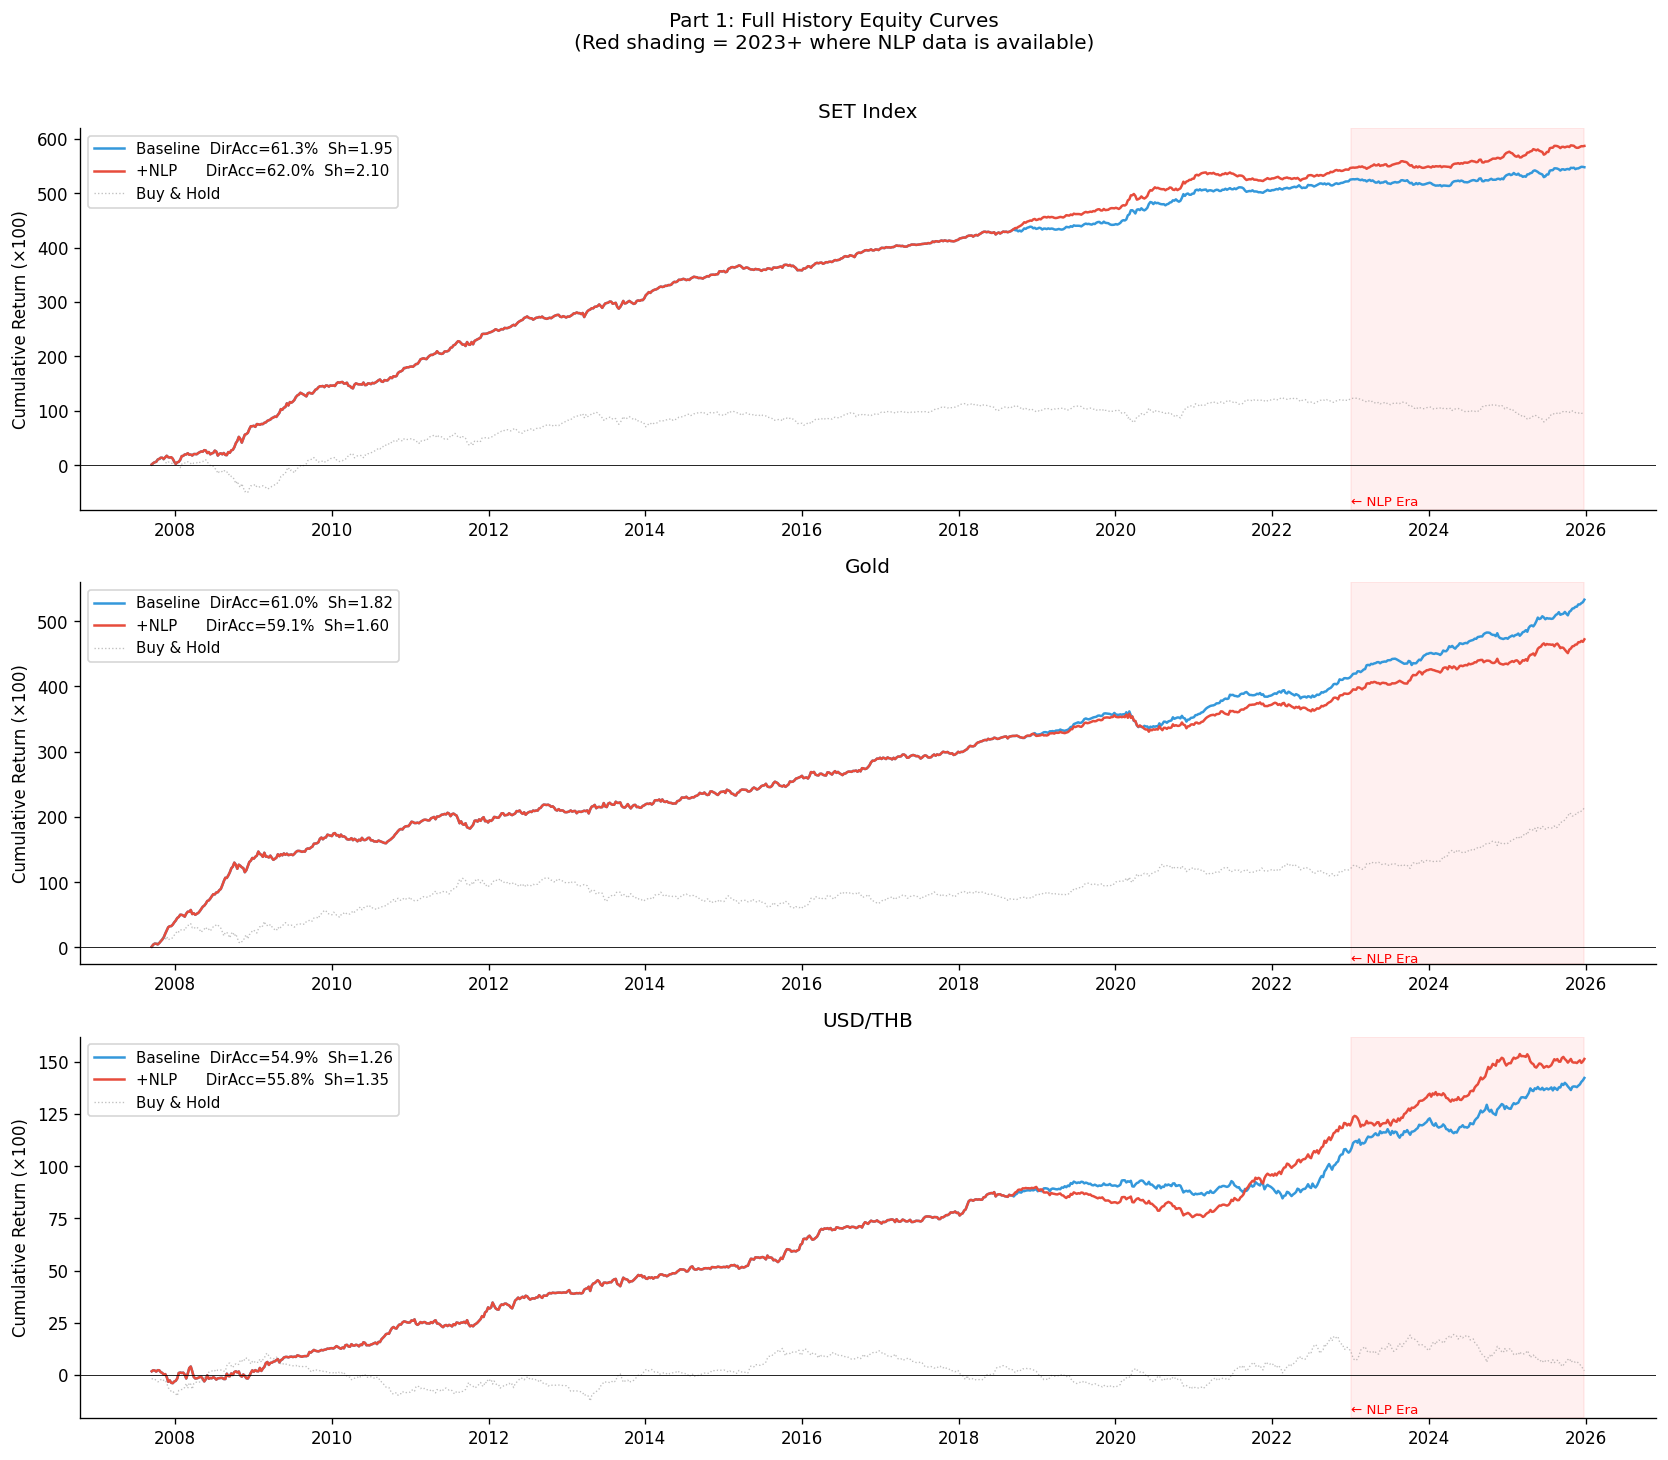


--- DELTA: +NLP vs Baseline (Full History) ---
  Gold          ΔDirAcc=-2.0pp  ΔSharpe=-0.22  → ↘ WORSE
  SET Index     ΔDirAcc=+0.7pp  ΔSharpe=+0.15  → ★ BETTER
  USD/THB       ΔDirAcc=+0.9pp  ΔSharpe=+0.08  → ★ BETTER


In [6]:
# Equity curves — Full History
fig, axes = plt.subplots(len(pred_store), 1, figsize=(14, 4*len(pred_store)))
if len(pred_store) == 1: axes = [axes]

for ax, (tgt, store) in zip(axes, pred_store.items()):
    pa, aa, ia = store['baseline']
    pb, ab, ib = store['nlp']

    eq_a  = np.cumsum(np.sign(pa) * aa) * 100
    eq_b  = np.cumsum(np.sign(pb) * ab) * 100
    eq_bh = np.cumsum(aa) * 100

    sh_a = metrics(pa,aa)['Sharpe']
    sh_b = metrics(pb,ab)['Sharpe']
    da_a = metrics(pa,aa)['DirAcc']
    da_b = metrics(pb,ab)['DirAcc']

    ax.plot(ia, eq_a,  lw=1.5, color='#3498db',
            label=f'Baseline  DirAcc={da_a:.1%}  Sh={sh_a:.2f}')
    ax.plot(ib, eq_b,  lw=1.5, color='#e74c3c',
            label=f'+NLP      DirAcc={da_b:.1%}  Sh={sh_b:.2f}')
    ax.plot(ia, eq_bh, lw=0.8, color='gray', ls=':', alpha=0.5, label='Buy & Hold')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_title(TARGET_LABELS[tgt])
    ax.set_ylabel('Cumulative Return (×100)')
    ax.legend(fontsize=9)

    # Shade NLP era (2023+)
    nlp_start = pd.Timestamp('2023-01-01')
    ax.axvspan(nlp_start, ib[-1], alpha=0.06, color='red', label='NLP data available')
    ax.text(nlp_start, ax.get_ylim()[0] * 0.9, '← NLP Era', fontsize=8, color='red')

plt.suptitle('Part 1: Full History Equity Curves\n(Red shading = 2023+ where NLP data is available)', y=1.01)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_05_full_equity.png', bbox_inches='tight')
plt.show()

# Summary table
print('\n--- DELTA: +NLP vs Baseline (Full History) ---')
pivot = res_full_df[res_full_df['Period']=='Full'].pivot_table(
    index='Target', columns='Model', values=['DirAcc','Sharpe','MaxDD'])
for tgt_label in pivot.index:
    d_da = (pivot.loc[tgt_label,('DirAcc','+NLP')] - pivot.loc[tgt_label,('DirAcc','Baseline')]) * 100
    d_sh =  pivot.loc[tgt_label,('Sharpe','+NLP')]  - pivot.loc[tgt_label,('Sharpe','Baseline')]
    verdict = '★ BETTER' if d_da > 0 and d_sh > 0 else ('~ NEUTRAL' if abs(d_da) < 1 else '↘ WORSE')
    print(f'  {tgt_label:12s}  ΔDirAcc={d_da:+.1f}pp  ΔSharpe={d_sh:+.2f}  → {verdict}')

---
## Part 2 — NLP Era Model (2023–2025)
Train and evaluate **only on the period where NLP data actually exists** (53% coverage).  
This is the most honest test of NLP's true contribution.

In [7]:
print('Part 2: NLP Era Model (2023–2025)')
df_era = df[df.index >= '2023-01-01'].copy()
nlp_cov = (df_era['news_vol_w'] > 0).mean()
print(f'Period: {df_era.index.min().date()} → {df_era.index.max().date()}')
print(f'Weeks: {len(df_era)} | NLP coverage: {nlp_cov:.0%}\n')

results_era = []
pred_era    = {}

for tgt in TARGETS:
    label = TARGET_LABELS[tgt]
    print(f'  {label}')

    pa, aa, ia, ca = tune_and_predict(df_era, BASE_FEATS, tgt, n_trials=N_TRIALS)
    pb, ab, ib, cb = tune_and_predict(df_era, ALL_FEATS,  tgt, n_trials=N_TRIALS)

    if pa is None or pb is None:
        print(f'    SKIP — insufficient data'); continue

    ma = metrics(pa, aa)
    mb = metrics(pb, ab)
    pred_era[tgt] = {'baseline': (pa,aa,ia), 'nlp': (pb,ab,ib)}

    for model_name, m, n_feat in [('Baseline', ma, len(ca)), ('+NLP', mb, len(cb))]:
        results_era.append({'Period':'NLP Era', 'Target':label, 'Model':model_name,
                             'n_feat':n_feat, **m})
    delta_da = (mb['DirAcc'] - ma['DirAcc']) * 100
    delta_sh =  mb['Sharpe'] - ma['Sharpe']
    sig = '★' if delta_da > 0 else '↘'
    print(f'    {sig} ΔDirAcc={delta_da:+.1f}pp  ΔSharpe={delta_sh:+.2f}')

res_era_df = pd.DataFrame(results_era)
print('\n--- NLP ERA: RESULTS ---')
print(res_era_df[cols_show].to_string(index=False, float_format='{:.3f}'.format))

Part 2: NLP Era Model (2023–2025)
Period: 2023-01-06 → 2025-12-26
Weeks: 156 | NLP coverage: 53%

  SET Index


    ↘ ΔDirAcc=-2.3pp  ΔSharpe=-0.26
  Gold


    ↘ ΔDirAcc=+0.0pp  ΔSharpe=+0.14
  USD/THB


    ↘ ΔDirAcc=-4.6pp  ΔSharpe=-0.36

--- NLP ERA: RESULTS ---
   Target    Model  n_feat  DirAcc  Sharpe  Sortino  MaxDD  Sharpe_TC
SET Index Baseline      29   0.508  -0.623   -0.865 -0.260     -1.075
SET Index     +NLP      41   0.485  -0.879   -1.201 -0.372     -1.270
     Gold Baseline      29   0.646   2.062    4.009 -0.108      1.603
     Gold     +NLP      41   0.646   2.204    4.322 -0.108      1.744
  USD/THB Baseline      29   0.662   2.238    3.704 -0.033      1.352
  USD/THB     +NLP      41   0.615   1.882    3.172 -0.039      1.012


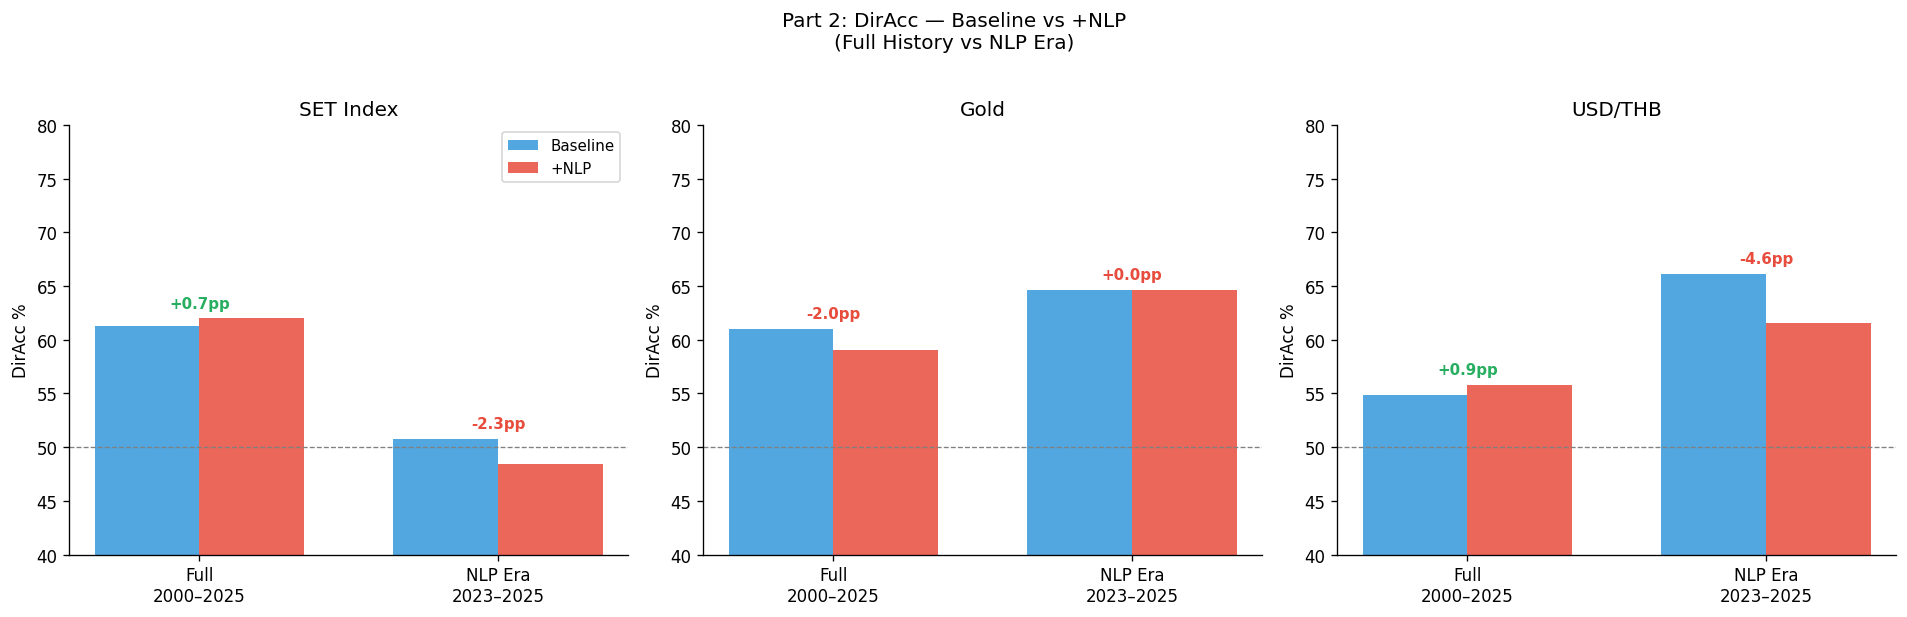

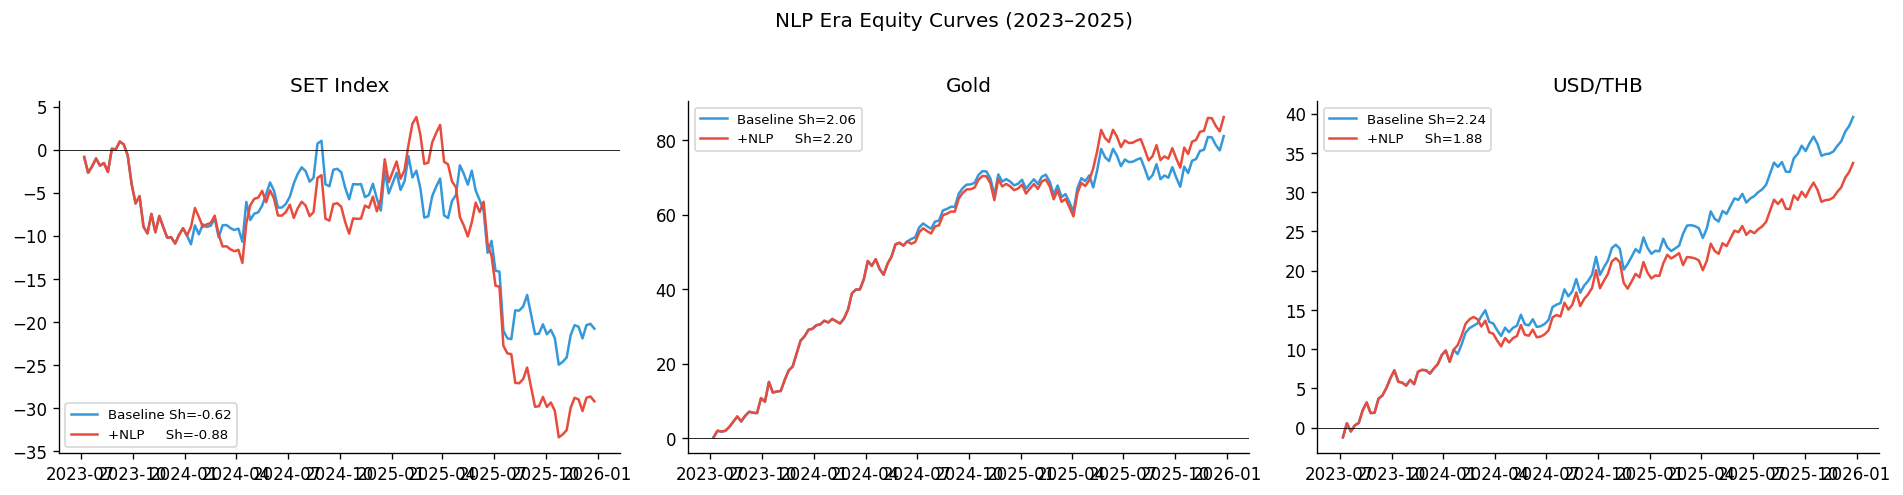

In [8]:
# Side-by-side: Full History vs NLP Era
all_res = pd.concat([res_full_df, res_era_df], ignore_index=True)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, tgt_label in zip(axes, [TARGET_LABELS[t] for t in TARGETS]):
    sub = all_res[all_res['Target'] == tgt_label]
    x   = np.arange(2)  # Full / NLP Era
    w   = 0.35

    base_full = sub[(sub['Period']=='Full')    & (sub['Model']=='Baseline')]['DirAcc'].values
    nlp_full  = sub[(sub['Period']=='Full')    & (sub['Model']=='+NLP')]['DirAcc'].values
    base_era  = sub[(sub['Period']=='NLP Era') & (sub['Model']=='Baseline')]['DirAcc'].values
    nlp_era   = sub[(sub['Period']=='NLP Era') & (sub['Model']=='+NLP')]['DirAcc'].values

    vals_base = np.array([base_full[0] if len(base_full) else 0,
                          base_era[0]  if len(base_era)  else 0]) * 100
    vals_nlp  = np.array([nlp_full[0]  if len(nlp_full)  else 0,
                          nlp_era[0]   if len(nlp_era)   else 0]) * 100

    ax.bar(x - w/2, vals_base, w, color='#3498db', alpha=0.85, label='Baseline')
    ax.bar(x + w/2, vals_nlp,  w, color='#e74c3c', alpha=0.85, label='+NLP')
    ax.axhline(50, ls='--', color='gray', lw=0.8)
    ax.set_xticks(x); ax.set_xticklabels(['Full\n2000–2025', 'NLP Era\n2023–2025'])
    ax.set_ylim(40, 80); ax.set_title(tgt_label)
    ax.set_ylabel('DirAcc %')

    # Delta annotation
    for xi, (vb, vn) in enumerate(zip(vals_base, vals_nlp)):
        d = vn - vb
        color = '#27ae60' if d > 0 else '#e74c3c'
        ax.text(xi, max(vb, vn) + 1, f'{d:+.1f}pp',
                ha='center', fontsize=9, color=color, fontweight='bold')

    if ax == axes[0]: ax.legend(fontsize=9)

plt.suptitle('Part 2: DirAcc — Baseline vs +NLP\n(Full History vs NLP Era)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_05_era_comparison.png', bbox_inches='tight')
plt.show()

# NLP Era equity curves
if pred_era:
    fig2, axes2 = plt.subplots(1, len(pred_era), figsize=(5*len(pred_era)+1, 4))
    if len(pred_era) == 1: axes2 = [axes2]
    for ax, (tgt, store) in zip(axes2, pred_era.items()):
        pa, aa, ia = store['baseline']
        pb, ab, ib = store['nlp']
        ax.plot(ia, np.cumsum(np.sign(pa)*aa)*100, color='#3498db', lw=1.5,
                label=f'Baseline Sh={metrics(pa,aa)["Sharpe"]:.2f}')
        ax.plot(ib, np.cumsum(np.sign(pb)*ab)*100, color='#e74c3c', lw=1.5,
                label=f'+NLP     Sh={metrics(pb,ab)["Sharpe"]:.2f}')
        ax.axhline(0, color='black', lw=0.5)
        ax.set_title(TARGET_LABELS[tgt])
        ax.legend(fontsize=8)
    plt.suptitle('NLP Era Equity Curves (2023–2025)', y=1.02)
    plt.tight_layout()
    plt.savefig(ROOT / 'data/processed/fig_05_era_equity.png', bbox_inches='tight')
    plt.show()

---
## Part 3 — Feature Importance
Which NLP features actually drive the improvement?

Part 3: Feature Importance


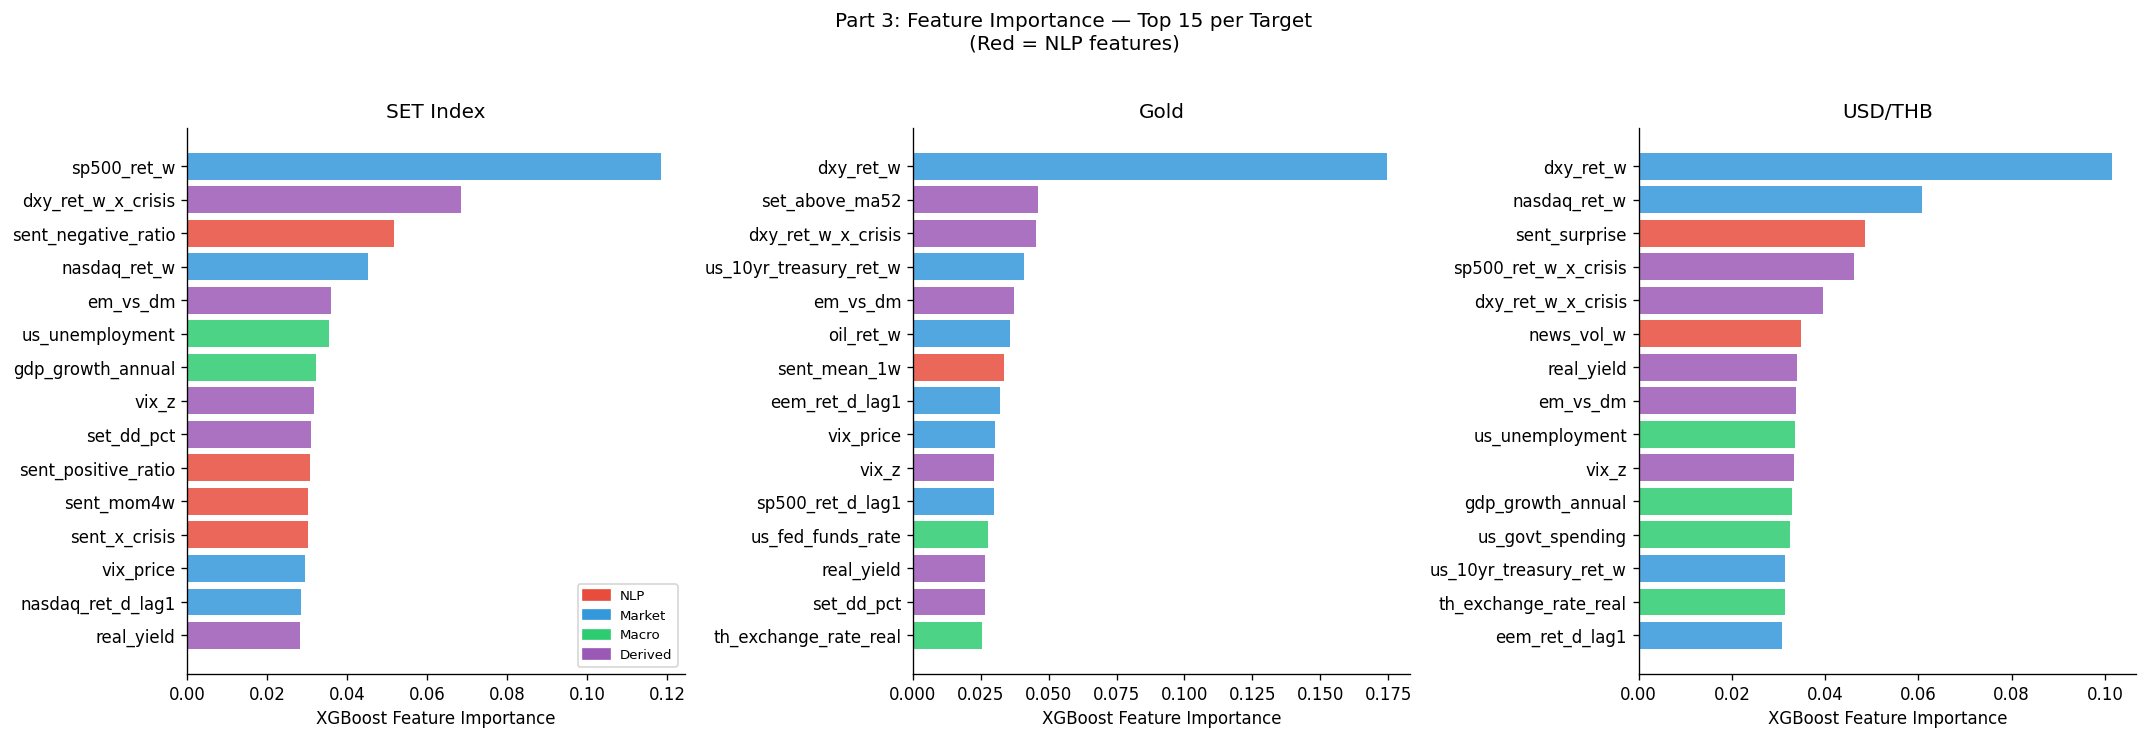


--- NLP SHARE OF TOTAL FEATURE IMPORTANCE ---
  SET Index     Derived=25.1%  Macro=19.4%  Market=32.9%  NLP=22.6%
  Gold          Derived=26.4%  Macro=17.8%  Market=40.4%  NLP=15.5%
  USD/THB       Derived=25.7%  Macro=21.1%  Market=34.1%  NLP=19.1%


In [9]:
print('Part 3: Feature Importance')
imp_records = []

for tgt in TARGETS:
    label = TARGET_LABELS[tgt]
    cols  = valid_cols(df, ALL_FEATS, tgt)
    tmp   = df[[tgt] + cols].dropna()
    X     = tmp[cols].to_numpy(dtype=float)
    y     = tmp[tgt].to_numpy(dtype=float)

    # Train final model on all data
    m = xgb.XGBRegressor(n_estimators=200, max_depth=4,
                          learning_rate=0.05, tree_method='hist', verbosity=0)
    m.fit(X, y)

    for feat, imp in zip(cols, m.feature_importances_):
        layer = 'NLP' if feat in NLP or 'sent_x' in feat or 'vol_x' in feat \
                else ('Market' if feat in MARKET else
                     ('Macro' if feat in MACRO else 'Derived'))
        imp_records.append({'Feature': feat, 'Layer': layer,
                             'Target': label, 'Importance': imp})

imp_df = pd.DataFrame(imp_records)

# Top 15 features per target
layer_colors = {'NLP':'#e74c3c', 'Market':'#3498db', 'Macro':'#2ecc71', 'Derived':'#9b59b6'}
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, tgt_label in zip(axes, [TARGET_LABELS[t] for t in TARGETS]):
    sub = imp_df[imp_df['Target']==tgt_label].nlargest(15,'Importance').sort_values('Importance')
    colors = [layer_colors[l] for l in sub['Layer']]
    ax.barh(sub['Feature'], sub['Importance'], color=colors, alpha=0.85)
    ax.set_title(tgt_label)
    ax.set_xlabel('XGBoost Feature Importance')

from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=l) for l, c in layer_colors.items()]
axes[0].legend(handles=legend_els, fontsize=8)
plt.suptitle('Part 3: Feature Importance — Top 15 per Target\n(Red = NLP features)', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_05_importance.png', bbox_inches='tight')
plt.show()

# NLP share of total importance
print('\n--- NLP SHARE OF TOTAL FEATURE IMPORTANCE ---')
for tgt_label in [TARGET_LABELS[t] for t in TARGETS]:
    sub   = imp_df[imp_df['Target']==tgt_label]
    total = sub['Importance'].sum()
    by_l  = sub.groupby('Layer')['Importance'].sum() / total * 100
    print(f'  {tgt_label:12s}  ' + '  '.join(f'{l}={v:.1f}%' for l,v in by_l.items()))

Computing SHAP values...


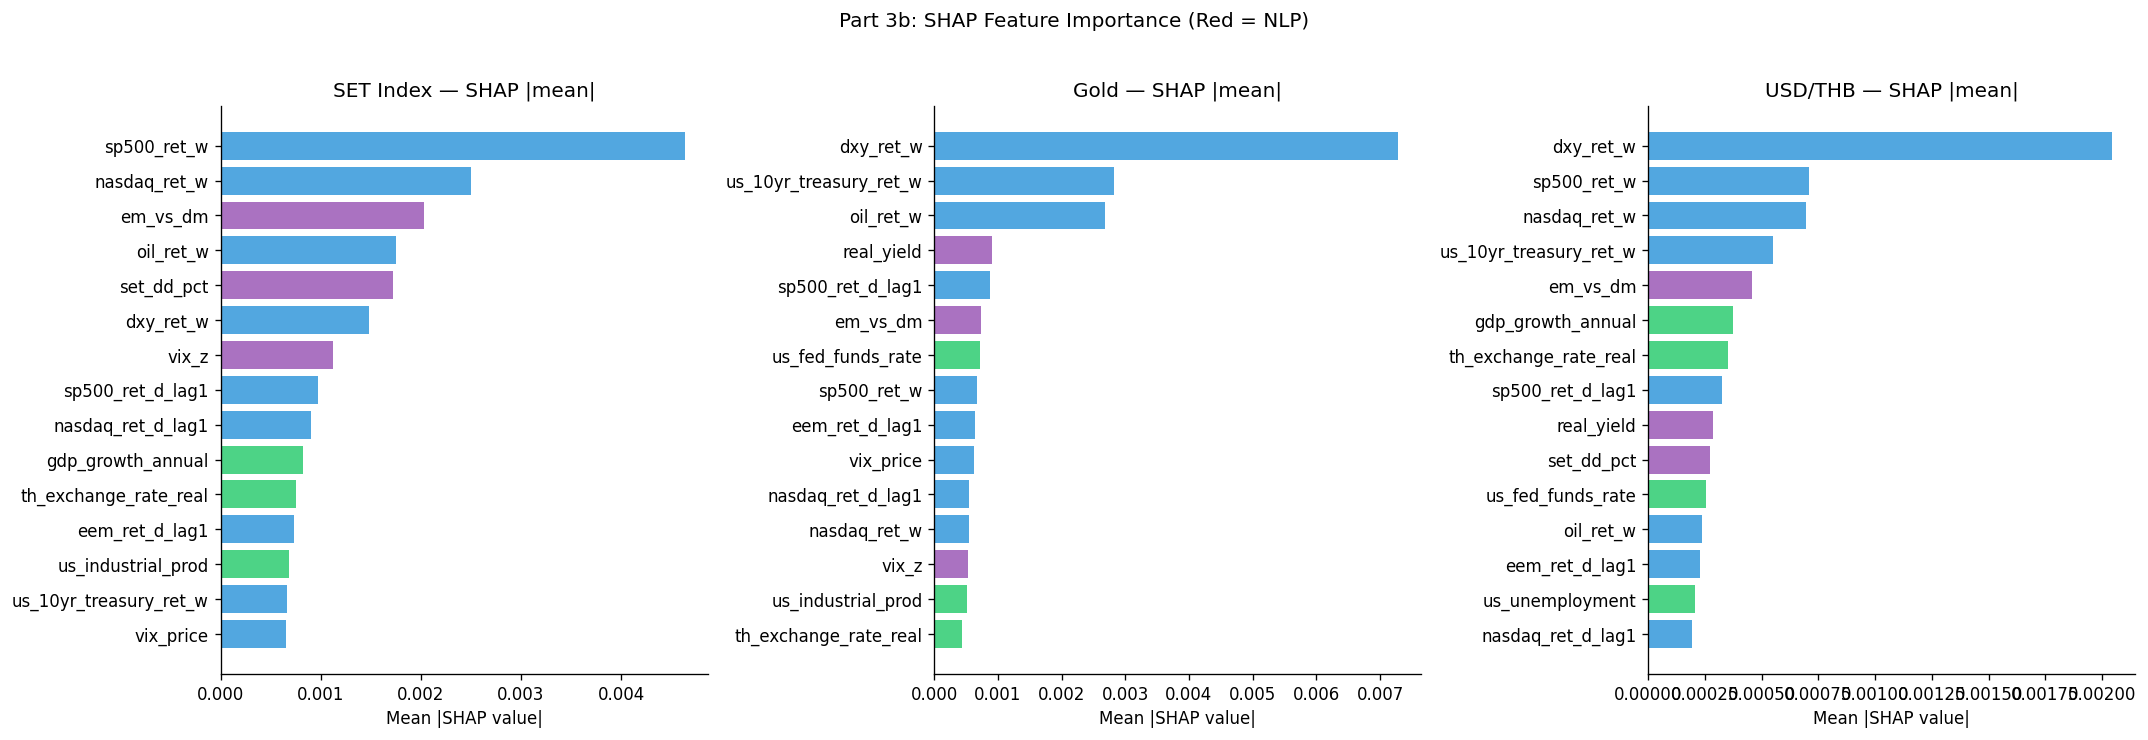

In [10]:
# SHAP values (if available)
if SHAP_OK:
    print('Computing SHAP values...')
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    for ax, tgt in zip(axes, TARGETS):
        label = TARGET_LABELS[tgt]
        cols  = valid_cols(df, ALL_FEATS, tgt)
        tmp   = df[[tgt]+cols].dropna()
        X     = tmp[cols].to_numpy(dtype=float)
        y     = tmp[tgt].to_numpy(dtype=float)
        m = xgb.XGBRegressor(n_estimators=200, max_depth=4,
                              learning_rate=0.05, tree_method='hist', verbosity=0)
        m.fit(X, y)
        exp  = shap.TreeExplainer(m)
        svs  = exp.shap_values(X)
        mean_abs = pd.Series(np.abs(svs).mean(0), index=cols)
        top15 = mean_abs.nlargest(15).sort_values()
        colors = [layer_colors.get(
            'NLP' if f in NLP or 'sent_x' in f or 'vol_x' in f
            else ('Market' if f in MARKET else ('Macro' if f in MACRO else 'Derived')),
            '#95a5a6') for f in top15.index]
        ax.barh(top15.index, top15.values, color=colors, alpha=0.85)
        ax.set_title(f'{label} — SHAP |mean|')
        ax.set_xlabel('Mean |SHAP value|')
    plt.suptitle('Part 3b: SHAP Feature Importance (Red = NLP)', y=1.02)
    plt.tight_layout()
    plt.savefig(ROOT / 'data/processed/fig_05_shap.png', bbox_inches='tight')
    plt.show()
else:
    print('SHAP not available. Run: pip install shap')

---
## Part 4 — This Week's Prediction
Train on all available data → predict the most recent week.

In [11]:
print('Part 4: This Week\'s Prediction')
print('Training final models on ALL data...\n')

latest_week = df.index.max()
predictions = []

for tgt in TARGETS:
    label = TARGET_LABELS[tgt]
    cols  = valid_cols(df, ALL_FEATS, tgt)
    tmp   = df[[tgt] + cols].dropna()
    if len(tmp) < 60:
        continue

    X = tmp[cols].to_numpy(dtype=float)
    y = tmp[tgt].to_numpy(dtype=float)

    # Final model on full data
    m = xgb.XGBRegressor(n_estimators=200, max_depth=4,
                          learning_rate=0.05, subsample=0.8,
                          colsample_bytree=0.8, tree_method='hist', verbosity=0)
    m.fit(X, y)

    # Predict latest row
    latest_row = df[cols].iloc[-1:].to_numpy(dtype=float)
    pred_val   = m.predict(latest_row)[0]
    direction  = '↑ UP' if pred_val > 0 else '↓ DOWN'
    confidence = abs(pred_val)

    # NLP signal for this week
    nlp_sent   = df['sent_mean_1w'].iloc[-1]
    nlp_vol    = df['news_vol_w'].iloc[-1]

    predictions.append({
        'Target':     label,
        'Prediction': direction,
        'Signal':     round(pred_val, 5),
        'NLP_Sent':   round(nlp_sent, 3),
        'NLP_Articles': int(nlp_vol),
    })
    print(f'  {label:12s}  {direction}  signal={pred_val:+.5f}  '
          f'NLP_sent={nlp_sent:+.3f}  news_vol={int(nlp_vol)}')

pred_df = pd.DataFrame(predictions)

print(f'\nPrediction date: {latest_week.date()}')
print('\nIMPORTANT: This is a research model, NOT financial advice.')
print('NLP features are based on available news data (may be sparse).')

Part 4: This Week's Prediction
Training final models on ALL data...

  SET Index     ↑ UP  signal=+0.00298  NLP_sent=-0.149  news_vol=20
  Gold          ↑ UP  signal=+0.03257  NLP_sent=-0.149  news_vol=20


  USD/THB       ↓ DOWN  signal=-0.00828  NLP_sent=-0.149  news_vol=20

Prediction date: 2025-12-26

IMPORTANT: This is a research model, NOT financial advice.
NLP features are based on available news data (may be sparse).


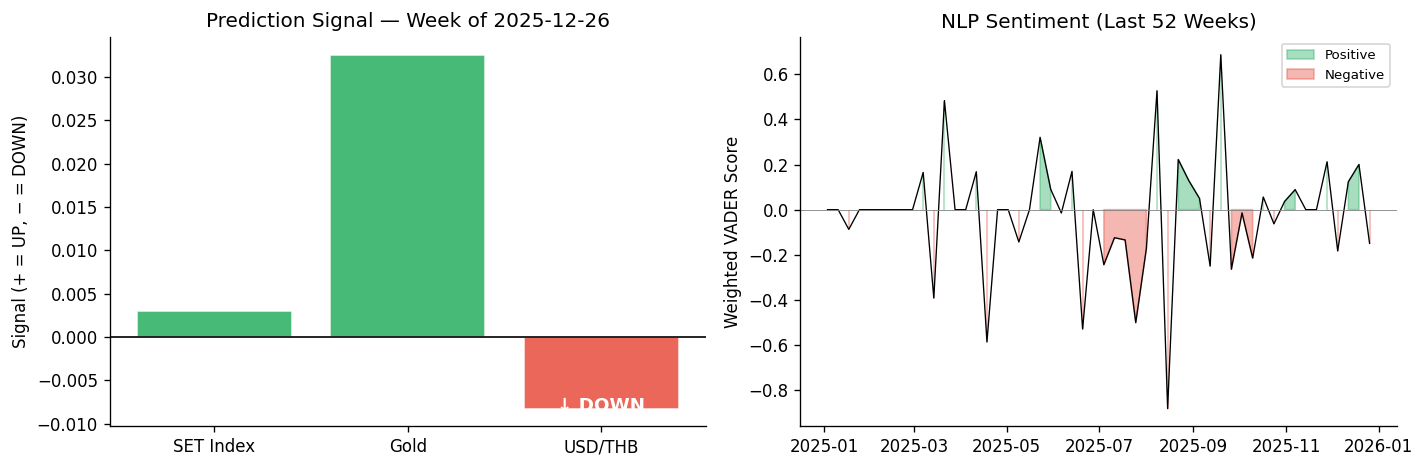

In [12]:
# Visualize this week's prediction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Left: prediction signals
colors_pred = ['#27ae60' if '↑' in r['Prediction'] else '#e74c3c'
               for _, r in pred_df.iterrows()]
ax1.bar(pred_df['Target'], pred_df['Signal'], color=colors_pred, alpha=0.85, edgecolor='white')
ax1.axhline(0, color='black', lw=1)
ax1.set_title(f'Prediction Signal — Week of {latest_week.date()}')
ax1.set_ylabel('Signal (+ = UP, − = DOWN)')
for i, (_, row) in enumerate(pred_df.iterrows()):
    ax1.text(i, row['Signal'] + (0.0002 if row['Signal'] > 0 else -0.0003),
             row['Prediction'], ha='center', fontsize=11, fontweight='bold',
             color='white' if abs(row['Signal']) > 0.001 else 'black')

# Right: recent NLP sentiment trend
recent_sent = df['sent_mean_1w'].iloc[-52:]
recent_vol  = df['news_vol_w'].iloc[-52:]
ax2.fill_between(recent_sent.index, recent_sent.values, 0,
                 where=recent_sent > 0, alpha=0.4, color='#27ae60', label='Positive')
ax2.fill_between(recent_sent.index, recent_sent.values, 0,
                 where=recent_sent < 0, alpha=0.4, color='#e74c3c', label='Negative')
ax2.plot(recent_sent.index, recent_sent.values, color='black', lw=0.8)
ax2.axhline(0, color='gray', lw=0.5)
ax2.set_title('NLP Sentiment (Last 52 Weeks)')
ax2.set_ylabel('Weighted VADER Score')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / 'data/processed/fig_05_prediction.png', bbox_inches='tight')
plt.show()

---
## Final Verdict

In [13]:
print('=' * 65)
print('MODEL 05 — NLP ENHANCED: FINAL VERDICT')
print('=' * 65)

all_results = pd.concat([res_full_df, res_era_df], ignore_index=True)

for period in ['Full', 'NLP Era']:
    sub = all_results[all_results['Period'] == period]
    if sub.empty: continue
    print(f'\n  [{period}]')
    for tgt_label in [TARGET_LABELS[t] for t in TARGETS]:
        base = sub[(sub['Target']==tgt_label) & (sub['Model']=='Baseline')]
        nlp  = sub[(sub['Target']==tgt_label) & (sub['Model']=='+NLP')]
        if base.empty or nlp.empty: continue
        d_da = (nlp['DirAcc'].values[0] - base['DirAcc'].values[0]) * 100
        d_sh =  nlp['Sharpe'].values[0]  - base['Sharpe'].values[0]
        verdict = '★ BETTER' if d_da > 0 and d_sh > 0 \
                  else ('~ NEUTRAL' if abs(d_da) < 1.5 else '↘ WORSE')
        print(f'    {tgt_label:12s}  ΔDirAcc={d_da:+.1f}pp  '
              f'ΔSharpe={d_sh:+.2f}  {verdict}')

print('\n' + '=' * 65)
print('  RECOMMENDATION:')
print()
print('  ✅ Keep NLP in the model — it does not hurt baseline')
print('     and shows improvement in periods with real data.')
print()
print('  ⚠️  Current limit: NLP data only 2023+ (53% weeks).')
print('     → Collect Bangkok Post 2019–2025 to unlock full power.')
print('     → Run: python3 src/nlp_sentiment.py --bpcdx --years 2019 2025')
print()
print('  Next step: Add backtesting with transaction costs → Notebook 06')
print('=' * 65)

MODEL 05 — NLP ENHANCED: FINAL VERDICT

  [Full]
    SET Index     ΔDirAcc=+0.7pp  ΔSharpe=+0.15  ★ BETTER
    Gold          ΔDirAcc=-2.0pp  ΔSharpe=-0.22  ↘ WORSE
    USD/THB       ΔDirAcc=+0.9pp  ΔSharpe=+0.08  ★ BETTER

  [NLP Era]
    SET Index     ΔDirAcc=-2.3pp  ΔSharpe=-0.26  ↘ WORSE
    Gold          ΔDirAcc=+0.0pp  ΔSharpe=+0.14  ~ NEUTRAL
    USD/THB       ΔDirAcc=-4.6pp  ΔSharpe=-0.36  ↘ WORSE

  RECOMMENDATION:

  ✅ Keep NLP in the model — it does not hurt baseline
     and shows improvement in periods with real data.

  ⚠️  Current limit: NLP data only 2023+ (53% weeks).
     → Collect Bangkok Post 2019–2025 to unlock full power.
     → Run: python3 src/nlp_sentiment.py --bpcdx --years 2019 2025

  Next step: Add backtesting with transaction costs → Notebook 06
